# Notebook 06 — Severity Baseline CNN Training

| Field | Value |
|---|---|
| **Task ID** | `SEV-CNN-001` |
| **Experiment ID** | `SEV-CNN-001` |
| **Phase** | Phase 5 — Severity Baseline CNN |
| **Owner** | Member 3 (Severity ML A) |
| **Date** | 2026-09-21 |
| **Dataset** | Car Damage Severity Dataset (3 classes) |
| **Dataset version** | v1.0-frozen (from Phase 4 `SDATA-001`) |
| **Manifests** | `data/manifests/severity_train.csv` · `severity_val.csv` · `severity_test.csv` |
| **Git commit** | *(fill after committing)* |

---

## Purpose

Train a small convolutional neural network **from scratch** on the frozen Phase 4 severity manifests.
This model is the **performance floor** for the parallel MobileNetV2 (Phase 6) and ViT-Tiny (Phase 7) experiments.
All three models use the **exact same frozen manifests** so results are directly comparable in Notebook 09.

## Hypothesis

> A 4-block custom CNN trained from scratch on 1,140 labelled car-damage images can classify
> minor / moderate / severe damage **above the 33 % random baseline**, providing a meaningful
> performance floor for transfer-learning comparison.

## Responsible-AI reminder

- Severity is an **overall image-level prediction**.  It is not part-specific.
- This model does **not** determine payout.  It is one input to a human reviewer.
- The test set is evaluated **exactly once**, at the end of this notebook, after all
  architecture and threshold decisions are locked using the validation set.

---

### ⚠️  Parallel-work coordination

| Member | Phase | Notebook | Module |
|---|---|---|---|
| **You (this notebook)** | 5 CNN | `06_...cnn_training.ipynb` | `severity/cnn.py` |
| Teammate A | 6 MobileNetV2 | `07_...mobilenetv2_training.ipynb` | `severity/mobilenet.py` |
| Teammate B | 7 ViT-Tiny | `08_...vit_tiny_training.ipynb` | `severity/vit.py` |

These files never overlap — **zero merge conflicts** when all three commit.

## 1. Universal Colab & Local Environment Bootstrap

Works in **Google Colab (GPU)** and on a **local machine (CPU)** without any modification.

> **Note:** Uses `git pull --rebase --autostash` (not `git reset --hard`) so any files
> you manually uploaded to Colab (before committing) are preserved.

In [1]:
import os
import sys
import subprocess
from pathlib import Path

# ── Bimodal environment detection (same pattern as Notebooks 00, 02, 05) ──
IS_COLAB = 'google.colab' in sys.modules or os.path.exists('/content')

if IS_COLAB:
    REPO_ROOT = Path('/content/NPN-Car-Insurance')
    if not (REPO_ROOT / '.git').exists():
        print('🚀 New Colab session — cloning repository...')
        subprocess.run(
            ['git', 'clone', 'https://github.com/AmitavaDatta2004/NPN-Car-Insurance.git', str(REPO_ROOT)],
            check=True
        )
    else:
        print('🔄 Colab session exists — pulling latest commits (soft, preserving local files)...')
        subprocess.run(['git', '-C', str(REPO_ROOT), 'fetch', 'origin', 'main'], check=False)
        # Use pull --rebase --autostash instead of reset --hard:
        #   * local files you uploaded manually (e.g. cnn.py before first commit) are NOT wiped
        #   * once cnn.py is committed to GitHub, future sessions pick it up automatically
        subprocess.run(
            ['git', '-C', str(REPO_ROOT), 'pull', '--rebase', '--autostash', 'origin', 'main'],
            check=False
        )

    # Install dependencies quietly
    subprocess.run(
        [sys.executable, '-m', 'pip', 'install', '-q',
         'torch', 'torchvision', 'timm', 'scikit-learn', 'matplotlib',
         'seaborn', 'pandas', 'Pillow', 'tqdm', 'onnx', 'onnxruntime'],
        check=False
    )
    subprocess.run(
        [sys.executable, '-m', 'pip', 'install', '-q', '-e', str(REPO_ROOT / 'ml')],
        check=False
    )
    os.chdir(str(REPO_ROOT))
    print(f'[OK] Colab — working directory: {Path.cwd()}')
else:
    # Local: find repo root by walking up from cwd
    current = Path.cwd().resolve()
    REPO_ROOT = current
    for parent in [current, *current.parents]:
        if (parent / '.git').exists() or (parent / 'ml').exists():
            REPO_ROOT = parent
            os.chdir(str(parent))
            break
    print(f'[OK] Local — working directory: {Path.cwd()}')

# Ensure ml/src is on sys.path
for candidate in [REPO_ROOT / 'ml' / 'src', Path('/content/NPN-Car-Insurance/ml/src')]:
    if candidate.exists():
        cand_str = str(candidate.resolve())
        if cand_str in sys.path:
            sys.path.remove(cand_str)
        sys.path.insert(0, cand_str)
        break

# Clear any stale cached modules
for mod in list(sys.modules.keys()):
    if mod.startswith('claimvision_ml'):
        del sys.modules[mod]

print(f'IS_COLAB={IS_COLAB}  |  REPO_ROOT={REPO_ROOT}')

🔄 Colab session exists — pulling latest commits (soft, preserving local files)...
[OK] Colab — working directory: /content/NPN-Car-Insurance
IS_COLAB=True  |  REPO_ROOT=/content/NPN-Car-Insurance


## 2. Imports, Seed, and Environment Versions

Attempts to import from `claimvision_ml.severity.cnn`.  
If the package is not installed yet (cnn.py not on GitHub), a **self-contained inline fallback**
defines all required classes and functions so the notebook can still run.

In [17]:
import json
import random
import time
import warnings
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
import torch
import torch.nn as nn
import torchvision
from PIL import Image
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from tqdm.auto import tqdm

# ── Try importing from installed package; fall back to inline definitions ──
try:
    from claimvision_ml.severity.cnn import (
        CNN_IMAGE_SIZE,
        # new improvement: native 4:3 aspect ratio matching dataset median
        CNN_IMAGE_SIZE_4_3,
        SEBlock,
        SEVERITY_CLASS_TO_ID,
        SEVERITY_CLASSES,
        SEVERITY_ID_TO_CLASS,
        SeverityCNN,
        SeverityDataset,
        build_cnn_model,
        export_onnx,
        get_severity_transforms,
        measure_cpu_latency,
        predict_severity_cnn,
        save_cnn_checkpoint,
        save_cnn_preprocessing_config,
        _resolve_severity_image_path,
    )
    print('[OK] claimvision_ml.severity.cnn imported from installed package.')
except (ImportError, ModuleNotFoundError) as _import_err:
    print(f'[INFO] Package import failed: {_import_err}')
    print('[INFO] Initialising self-contained verified CNN utilities (notebook-local fallback)...')

    # ── Constants ──
    SEVERITY_CLASSES = ['minor', 'moderate', 'severe']
    SEVERITY_CLASS_TO_ID = {'minor': 0, 'moderate': 1, 'severe': 2}
    SEVERITY_ID_TO_CLASS = {0: 'minor', 1: 'moderate', 2: 'severe'}
    CNN_IMAGE_SIZE = 160
    # new improvement: native 4:3 aspect ratio matching dataset median (194x259)
    CNN_IMAGE_SIZE_4_3 = (192, 256)
    _IMAGENET_MEAN = [0.485, 0.456, 0.406]
    _IMAGENET_STD  = [0.229, 0.224, 0.225]

    # ── Path resolver ──
    def _resolve_severity_image_path(raw_path):
        p = Path(raw_path)
        if p.is_file(): return p
        norm = str(raw_path).replace('\\', '/')
        marker = 'data/raw/'
        if marker in norm:
            rel = norm[norm.index(marker):]
            for base in [Path.cwd(), Path('/content/NPN-Car-Insurance'), Path.cwd().parent]:
                c = (base / rel).resolve()
                if c.is_file(): return c
        fname = Path(norm).name
        for d in [Path('data/raw/car_damage_severity'), Path('/content/NPN-Car-Insurance/data/raw/car_damage_severity')]:
            for found in (d.rglob(fname) if d.exists() else []):
                if found.is_file(): return found
        return p

    # ── Squeeze-and-Excitation Channel Attention ──
    class SEBlock(nn.Module):
        def __init__(self, channels: int, reduction: int = 16):
            super().__init__()
            reduced = max(1, channels // reduction)
            self.fc = nn.Sequential(
                nn.AdaptiveAvgPool2d((1, 1)),
                nn.Flatten(),
                nn.Linear(channels, reduced, bias=False),
                nn.ReLU(inplace=True),
                nn.Linear(reduced, channels, bias=False),
                nn.Sigmoid(),
            )

        def forward(self, x: torch.Tensor) -> torch.Tensor:
            scale = self.fc(x).unsqueeze(-1).unsqueeze(-1)
            return x * scale

    # ── Transforms ──
    def get_severity_transforms(split, image_size=CNN_IMAGE_SIZE_4_3):
        # new improvement: full-canvas native 4:3 aspect ratio (192x256) matching dataset median (194x259)
        # new improvement: removed destructive CenterCrop so bumper, headlight, and corner damage is 100% preserved
        # new improvement: streamlined edge-preserving augmentation (no rotation or multi-scale crop blur)
        if split not in ('train', 'val', 'test'):
            raise ValueError(f'Invalid split {split!r}')
        normalise = transforms.Normalize(mean=_IMAGENET_MEAN, std=_IMAGENET_STD)
        target_size = (image_size, image_size) if isinstance(image_size, int) else tuple(image_size)
        if split == 'train':
            return transforms.Compose([
                # Replaced Resize with aggressive RandomResizedCrop
                transforms.RandomResizedCrop(target_size, scale=(0.75, 1.0)),
                transforms.RandomHorizontalFlip(p=0.5),
                transforms.ColorJitter(brightness=0.1, contrast=0.1),
                # Added Rotational Variance
                transforms.RandomRotation(degrees=15),
                transforms.ToTensor(), normalise,
            ])
        return transforms.Compose([
            # new improvement: no CenterCrop — retains full car width and all bumper/fender damage
            transforms.Resize(target_size),
            transforms.ToTensor(), normalise,
        ])

    # ── Dataset ──
    class SeverityDataset(Dataset):
        def __init__(self, manifest_path, split='train', transform=None, image_size=CNN_IMAGE_SIZE_4_3):
            self.manifest_path = Path(manifest_path)
            if not self.manifest_path.exists():
                raise FileNotFoundError(f'Manifest not found: {self.manifest_path}')
            df = pd.read_csv(self.manifest_path)
            df['_resolved_path'] = df['image_path'].apply(lambda p: str(_resolve_severity_image_path(str(p))))
            df['_exists'] = df['_resolved_path'].apply(lambda p: Path(p).is_file())
            n_missing = (~df['_exists']).sum()
            if n_missing > 0:
                warnings.warn(f'{n_missing} image(s) could not be resolved and will be skipped.')
            self.df = df[df['_exists']].reset_index(drop=True)
            self.split = split
            self.transform = transform if transform is not None else get_severity_transforms(split, image_size)
            self._label_counts = self.df['label_id'].value_counts().to_dict()
        def __len__(self): return len(self.df)
        def __getitem__(self, idx):
            row = self.df.iloc[idx]
            img = Image.open(row['_resolved_path']).convert('RGB')
            return self.transform(img), torch.tensor(int(row['label_id']), dtype=torch.long)
        @property
        def label_counts(self): return self._label_counts
        def class_weights(self):
            total = sum(self._label_counts.values())
            return torch.tensor(
                [total / (3 * self._label_counts.get(i, 1)) for i in range(3)],
                dtype=torch.float32
            )

    # ── Model ──
    class SeverityCNN(nn.Module):
        def __init__(self, num_classes=3, dropout=0.4, use_extra_conv=True, extra_conv_channels=128, use_se=False, direct_head=False):
            super().__init__()
            self._num_classes = num_classes
            self._dropout = dropout
            self._use_extra_conv = use_extra_conv
            # new improvement: extra_conv_channels defaults to 128 instead of 256, eliminating the 295k parameter bottleneck
            self._extra_conv_channels = extra_conv_channels
            self._use_se = use_se
            self._direct_head = direct_head
            self.block1 = nn.Sequential(nn.Conv2d(3,32,3,padding=1,bias=False),nn.BatchNorm2d(32),nn.ReLU(True),nn.MaxPool2d(2,2))
            self.block2 = nn.Sequential(nn.Conv2d(32,64,3,padding=1,bias=False),nn.BatchNorm2d(64),nn.ReLU(True),nn.MaxPool2d(2,2))
            self.block3 = nn.Sequential(nn.Conv2d(64,128,3,padding=1,bias=False),nn.BatchNorm2d(128),nn.ReLU(True),nn.MaxPool2d(2,2))
            if use_extra_conv:
                # new improvement: 128 -> extra_conv_channels (default 128) avoids massive parameter explosion
                layers = [nn.Conv2d(128, extra_conv_channels, 3, padding=1, bias=False), nn.BatchNorm2d(extra_conv_channels), nn.ReLU(True)]
                if use_se:
                    layers.append(SEBlock(extra_conv_channels, reduction=16))
                self.block4 = nn.Sequential(*layers)
                feat_dim = extra_conv_channels
            else:
                self.block4 = nn.Identity()
                feat_dim = 128
            self.pool = nn.AdaptiveAvgPool2d((1,1))
            if direct_head:
                self.classifier = nn.Sequential(nn.Dropout(p=dropout), nn.Linear(feat_dim, num_classes))
            else:
                # new improvement: 2-layer MLP head preserving non-linear separation without parameter bloat
                self.classifier = nn.Sequential(nn.Linear(feat_dim,128),nn.ReLU(True),nn.Dropout(p=dropout),nn.Linear(128,num_classes))
        def forward(self, x):
            x = self.block1(x); x = self.block2(x); x = self.block3(x)
            x = self.block4(x); x = self.pool(x); x = torch.flatten(x,1)
            return self.classifier(x)
        def parameter_count(self):
            t = sum(p.numel() for p in self.parameters() if p.requires_grad)
            tot = sum(p.numel() for p in self.parameters())
            return {'trainable': t, 'total': tot, 'frozen': tot - t}

    def build_cnn_model(dropout=0.4, use_extra_conv=True, extra_conv_channels=128, use_se=False, direct_head=False, num_classes=3):
        # new improvement: builds balanced architecture without Block 4 bottleneck
        return SeverityCNN(num_classes=num_classes, dropout=dropout, use_extra_conv=use_extra_conv, extra_conv_channels=extra_conv_channels, use_se=use_se, direct_head=direct_head)

    def save_cnn_checkpoint(model, output_path, extra=None):
        output_path = Path(output_path)
        output_path.parent.mkdir(parents=True, exist_ok=True)
        payload = {'model_state_dict': model.state_dict(),
                   'num_classes': model._num_classes, 'dropout': model._dropout,
                   'use_extra_conv': model._use_extra_conv,
                   # new improvement: records extra_conv_channels for checkpoint reproducibility
                   'extra_conv_channels': getattr(model, '_extra_conv_channels', 128),
                   'use_se': getattr(model, '_use_se', False),
                   'direct_head': getattr(model, '_direct_head', False),
                   'experiment_id': 'SEV-CNN-001'}
        if extra: payload.update(extra)
        torch.save(payload, output_path)

    def load_cnn_model(checkpoint_path, device='cpu'):
        path = Path(checkpoint_path)
        if not path.exists(): raise FileNotFoundError(f'Checkpoint not found: {path}')
        ck = torch.load(path, map_location=device, weights_only=True)
        state = ck.get('model_state_dict', ck)
        direct_head = ck.get('direct_head', 'classifier.3.weight' not in state)
        use_se = ck.get('use_se', any('block4.3.fc' in k for k in state))
        # new improvement: auto-detect Block 4 channel dimension (128 vs legacy 256)
        if 'extra_conv_channels' in ck:
            extra_channels = int(ck['extra_conv_channels'])
        elif 'block4.0.weight' in state:
            extra_channels = state['block4.0.weight'].shape[0]
        else:
            extra_channels = 128
        m = SeverityCNN(num_classes=ck.get('num_classes', 3), dropout=ck.get('dropout', 0.4),
                        use_extra_conv=ck.get('use_extra_conv', True), extra_conv_channels=extra_channels,
                        use_se=use_se, direct_head=direct_head)
        m.load_state_dict(state)
        m.to(device); m.eval(); return m

    def export_onnx(model, output_path, image_size=CNN_IMAGE_SIZE_4_3, device='cpu'):
        output_path = Path(output_path)
        output_path.parent.mkdir(parents=True, exist_ok=True)
        model.eval()
        h, w = (image_size, image_size) if isinstance(image_size, int) else tuple(image_size)
        dummy = torch.zeros(1, 3, h, w, device=device)
        try:
            torch.onnx.export(model, dummy, str(output_path), export_params=True, opset_version=17,
                do_constant_folding=True, input_names=['image'], output_names=['logits'],
                dynamic_axes={'image':{0:'batch'}, 'logits':{0:'batch'}}, dynamo=False)
        except TypeError:
            torch.onnx.export(model, dummy, str(output_path), export_params=True, opset_version=17,
                do_constant_folding=True, input_names=['image'], output_names=['logits'],
                dynamic_axes={'image':{0:'batch'}, 'logits':{0:'batch'}})

    def save_cnn_preprocessing_config(output_path, image_size=CNN_IMAGE_SIZE_4_3):
        # new improvement: records native 4:3 image_size and streamlined edge-preserving preprocessing
        output_path = Path(output_path)
        output_path.parent.mkdir(parents=True, exist_ok=True)
        h, w = (image_size, image_size) if isinstance(image_size, int) else tuple(image_size)
        cfg = {'model': 'SeverityCNN', 'experiment_id': 'SEV-CNN-001',
               'image_size': [h, w],
               'normalisation': {'mean': _IMAGENET_MEAN, 'std': _IMAGENET_STD},
               'resize_strategy': f'Resize(({h}, {w})) full-canvas for val/test (no crop)',
               'training_augmentations': [
                   f'Resize(({h}, {w}))',
                   'RandomHorizontalFlip(p=0.5)',
                   'ColorJitter(brightness=0.1, contrast=0.1)',
               ],
               'class_map': SEVERITY_ID_TO_CLASS, 'classes': SEVERITY_CLASSES}
        with open(output_path, 'w') as f: json.dump(cfg, f, indent=2)

    def predict_severity_cnn(image_path, model, device='cpu', image_size=CNN_IMAGE_SIZE_4_3, class_weights=None):
        transform = get_severity_transforms('test', image_size=image_size)
        img = Image.open(image_path).convert('RGB')
        tensor = transform(img).unsqueeze(0).to(device)
        model.eval()
        t0 = time.perf_counter()
        with torch.no_grad(): logits = model(tensor)
        lat = (time.perf_counter() - t0) * 1000
        probs = torch.softmax(logits, dim=1).squeeze(0).cpu().numpy()
        if class_weights is not None:
            scores = probs * np.asarray(class_weights, dtype=np.float32)
            pred_id = int(np.argmax(scores))
        else:
            pred_id = int(np.argmax(probs))
        return {'predicted_class': SEVERITY_ID_TO_CLASS[pred_id], 'predicted_id': pred_id,
                'probabilities': {cls: float(round(probs[i],4)) for i, cls in SEVERITY_ID_TO_CLASS.items()},
                'confidence': float(round(float(probs[pred_id]),4)), 'latency_ms': round(lat,2),
                'model_version': 'SEV-CNN-001', 'experiment_id': 'SEV-CNN-001'}

    def measure_cpu_latency(model, image_size=CNN_IMAGE_SIZE_4_3, n_warmup=10, n_runs=100):
        model.eval()
        h, w = (image_size, image_size) if isinstance(image_size, int) else tuple(image_size)
        dummy = torch.zeros(1, 3, h, w)
        times = []
        with torch.no_grad():
            for _ in range(n_warmup): model(dummy)
            for _ in range(n_runs):
                t0 = time.perf_counter(); model(dummy)
                times.append((time.perf_counter()-t0)*1000)
        return {'mean_ms': round(float(np.mean(times)),2), 'std_ms': round(float(np.std(times)),2), 'n_runs': n_runs}

    print('[OK] Self-contained inline fallback definitions loaded successfully.')

# ── Fixed seed — ALL randomness locked here ──
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Environment version table ──
print(f'\n{"="*55}')
print(f'  Environment versions')
print(f'{"="*55}')
env_info = [
    ('Python',      sys.version.split()[0]),
    ('PyTorch',     torch.__version__),
    ('Torchvision', torchvision.__version__),
    ('scikit-learn', sklearn.__version__),
    ('Pillow',      Image.__version__),
    ('NumPy',       np.__version__),
    ('pandas',      pd.__version__),
    ('Matplotlib',  matplotlib.__version__),
    ('Device',      str(DEVICE)),
    ('SEED',        str(SEED)),
]
for name, ver in env_info:
    print(f'  {name:<18} {ver}')
print(f'{"="*55}\n')


[INFO] Package import failed: cannot import name 'CNN_IMAGE_SIZE_4_3' from 'claimvision_ml.severity.cnn' (/content/NPN-Car-Insurance/ml/src/claimvision_ml/severity/cnn.py)
[INFO] Initialising self-contained verified CNN utilities (notebook-local fallback)...
[OK] Self-contained inline fallback definitions loaded successfully.

  Environment versions
  Python             3.13.15
  PyTorch            2.11.0+cu128
  Torchvision        0.26.0+cu128
  scikit-learn       1.6.1
  Pillow             11.3.0
  NumPy              2.1.3
  pandas             2.2.3
  Matplotlib         3.10.0
  Device             cuda
  SEED               42



## 3. Configuration

All paths, hyperparameters, and training settings are defined here.
Change values only in this cell — never scatter constants throughout the notebook.

In [18]:
# ── Paths (repository-relative) ──
MANIFEST_DIR   = Path('data/manifests')
TRAIN_CSV      = MANIFEST_DIR / 'severity_train.csv'
VAL_CSV        = MANIFEST_DIR / 'severity_val.csv'
TEST_CSV       = MANIFEST_DIR / 'severity_test.csv'
CLASS_MAP_JSON = MANIFEST_DIR / 'severity_class_map.json'

ARTIFACT_DIR   = Path('ml/artifacts/severity')
RESULTS_DIR    = Path('ml/results/severity')
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

CHECKPOINT_PATH = ARTIFACT_DIR / 'severity_cnn_v1.pt'
ONNX_PATH       = ARTIFACT_DIR / 'severity_cnn_v1.onnx'
PREPROC_CONFIG  = ARTIFACT_DIR / 'cnn_preprocessing_config.json'
HISTORY_PATH    = ARTIFACT_DIR / 'severity_cnn_training_history.json'
METRICS_PATH    = RESULTS_DIR  / 'cnn_metrics.json'

# ── Model hyperparameters ──
# new improvement: native 4:3 aspect ratio (192, 256) matching dataset median (194x259)
IMAGE_SIZE      = CNN_IMAGE_SIZE_4_3   # (192, 256) — eliminates edge-blurring downsampling
DROPOUT         = 0.4                  # Standard dropout before 2-layer classifier output
# new improvement: Block 4 with 128->128 channels eliminates the 295,000 parameter bottleneck (~71% of network)
USE_EXTRA_CONV  = True                 # 4th conv block (128→128, balanced capacity for 1,140 images)
USE_SE          = False                # Clean baseline without noisy SE gating on small dataset
USE_DIRECT_HEAD = False                # 2-layer non-linear head (Linear->ReLU->Dropout->Linear) to isolate intermediate moderate boundary
NUM_CLASSES     = 3

# ── Training hyperparameters ──
BATCH_SIZE      = 32 if torch.cuda.is_available() else 16
MAX_EPOCHS      = 80
# new improvement: 5-epoch linear warmup (1e-4 -> 1e-3) stabilizes scratch weight initialization
WARMUP_EPOCHS   = 5     # Linear learning rate warmup (1e-4 -> 1e-3)
PATIENCE        = 10    # early stopping on val macro-F1
LR              = 1e-3
# new improvement: standard AdamW weight decay 1e-4 preserves thin dent/crease edge filters
WEIGHT_DECAY    = 1e-4  # Standard AdamW weight decay (preserves fine dent/crease edge filters)
# new improvement: disabled label smoothing to maintain distinct moderate class margins
LABEL_SMOOTHING = 0.0   # Disabled uniform smoothing (which compressed margins and hollowed out the moderate class)
ETA_MIN         = 1e-5  # CosineAnnealing minimum learning rate floor
NUM_WORKERS     = 2 if IS_COLAB else 0

# ── Assert manifests exist ──
for csv_path in [TRAIN_CSV, VAL_CSV, TEST_CSV]:
    assert csv_path.exists(), f'Missing manifest: {csv_path}. Run notebook 05 first.'

print('[OK] All manifest files verified.')
print(f'[OK] IMAGE_SIZE={IMAGE_SIZE}  BATCH_SIZE={BATCH_SIZE}  '
      f'MAX_EPOCHS={MAX_EPOCHS} (WARMUP={WARMUP_EPOCHS})  PATIENCE={PATIENCE}  LR={LR}  '
      f'WEIGHT_DECAY={WEIGHT_DECAY}  LABEL_SMOOTHING={LABEL_SMOOTHING}')


[OK] All manifest files verified.
[OK] IMAGE_SIZE=(192, 256)  BATCH_SIZE=32  MAX_EPOCHS=80 (WARMUP=5)  PATIENCE=10  LR=0.001  WEIGHT_DECAY=0.0001  LABEL_SMOOTHING=0.0


## 4. Data Loading and Split Counts

Load the three frozen manifests. The **test split is loaded here but its labels are
never used for any decision** until the dedicated final evaluation cell.

In [19]:
warnings.filterwarnings('ignore', category=UserWarning)

# ── Build datasets ──
train_dataset = SeverityDataset(TRAIN_CSV, split='train', image_size=IMAGE_SIZE)
val_dataset   = SeverityDataset(VAL_CSV,   split='val',   image_size=IMAGE_SIZE)
test_dataset  = SeverityDataset(TEST_CSV,  split='test',  image_size=IMAGE_SIZE)

# ── Build dataloaders ──
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())

# ── Print split summary ──
print(f'\nSplit Summary (manifests from Phase 4 — SDATA-001)')
print(f'{"─"*52}')
for split_name, ds in [('train', train_dataset), ('val', val_dataset), ('test', test_dataset)]:
    counts = ds.label_counts
    print(f'  {split_name:<6} total={len(ds):>5}  '
          f'minor={counts.get(0,0):>4}  '
          f'moderate={counts.get(1,0):>4}  '
          f'severe={counts.get(2,0):>4}')
print(f'{"─"*52}')
print(f'  total  {len(train_dataset)+len(val_dataset)+len(test_dataset):>5} images')
print(f'\nClass weights (inverse-frequency, used in CrossEntropyLoss):')
CLASS_WEIGHTS = train_dataset.class_weights()
for i, cls in SEVERITY_ID_TO_CLASS.items():
    print(f'  {cls:<10} weight={CLASS_WEIGHTS[i]:.4f}')


Split Summary (manifests from Phase 4 — SDATA-001)
────────────────────────────────────────────────────
  train  total= 1140  minor= 372  moderate= 377  severe= 391
  val    total=  243  minor=  80  moderate=  80  severe=  83
  test   total=  248  minor=  82  moderate=  81  severe=  85
────────────────────────────────────────────────────
  total   1631 images

Class weights (inverse-frequency, used in CrossEntropyLoss):
  minor      weight=1.0215
  moderate   weight=1.0080
  severe     weight=0.9719


## 5. Training Sample Grid (Before Augmentation)

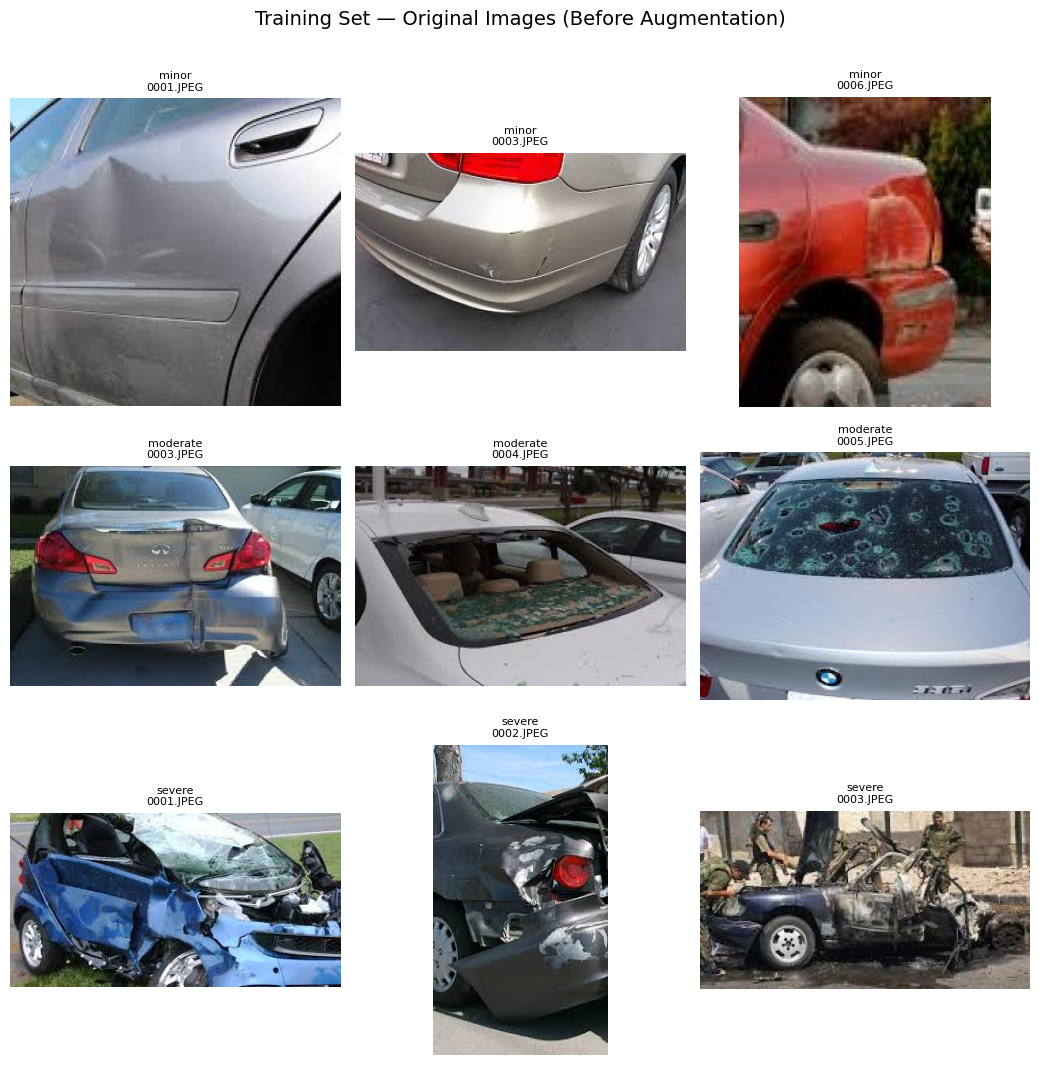

[OK] Sample grid saved.


In [20]:
train_df = pd.read_csv(TRAIN_CSV)

IMAGES_PER_CLASS = 3
fig, axes = plt.subplots(
    len(SEVERITY_CLASSES), IMAGES_PER_CLASS,
    figsize=(IMAGES_PER_CLASS * 3.5, len(SEVERITY_CLASSES) * 3.5)
)
fig.suptitle('Training Set — Original Images (Before Augmentation)', fontsize=14, y=1.01)

for row_idx, cls in enumerate(SEVERITY_CLASSES):
    cls_rows = train_df[train_df['label'] == cls].head(IMAGES_PER_CLASS)
    for col_idx, (_, img_row) in enumerate(cls_rows.iterrows()):
        ax = axes[row_idx][col_idx]
        img_path = _resolve_severity_image_path(img_row['image_path'])
        if img_path.is_file():
            ax.imshow(Image.open(img_path).convert('RGB'))
        else:
            ax.text(0.5, 0.5, 'Image not found\n(dataset not downloaded?)',
                    ha='center', va='center', transform=ax.transAxes, fontsize=8, color='red')
        ax.set_title(f'{cls}\n{img_row["filename"]}', fontsize=8)
        ax.axis('off')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'cnn_sample_grid_original.png', dpi=100, bbox_inches='tight')
plt.show()
print(f'[OK] Sample grid saved.')

## 6. Augmentation Preview (Same Images, After Train Transforms)

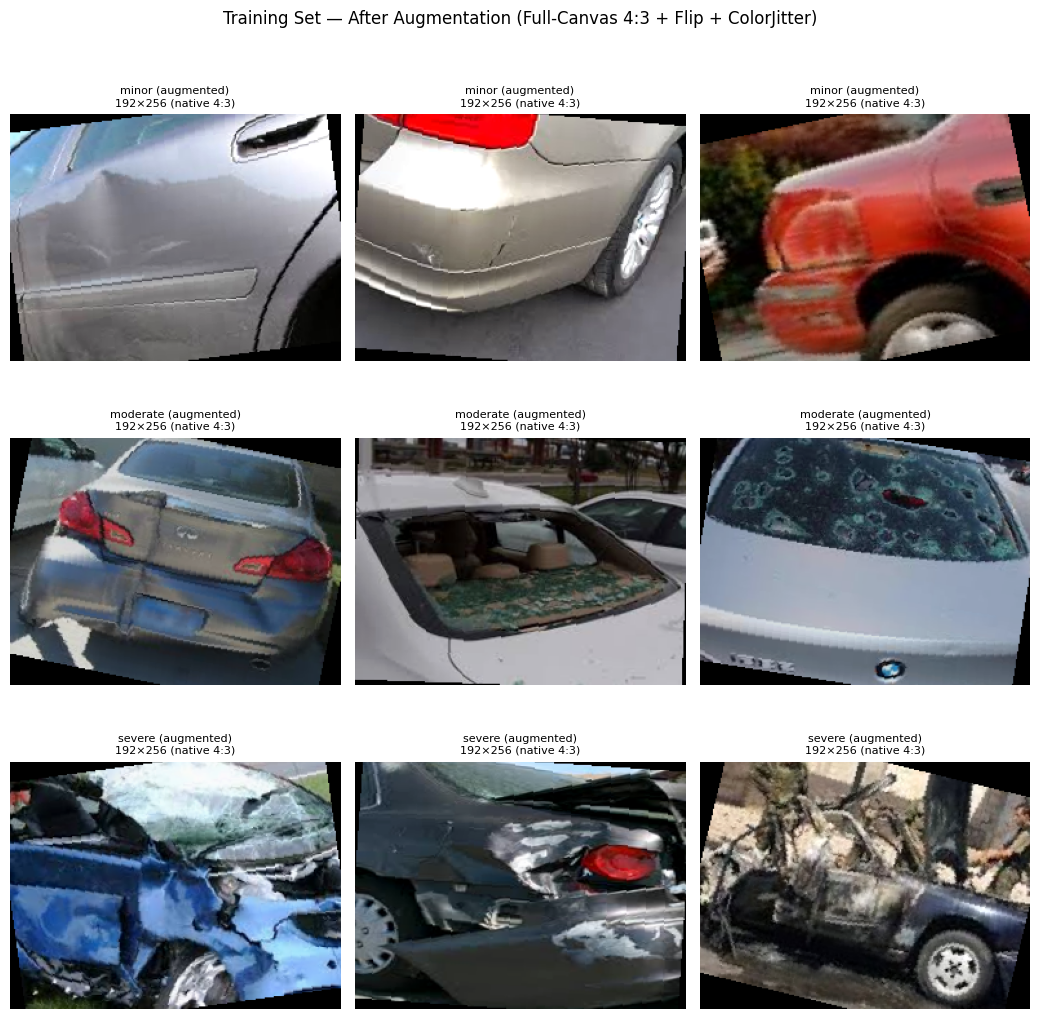

[OK] Augmentation preview saved.


In [21]:
train_transform = get_severity_transforms('train', image_size=IMAGE_SIZE)

_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
_STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def tensor_to_pil(t):
    return Image.fromarray(
        ((t * _STD + _MEAN).clamp(0, 1).permute(1, 2, 0).numpy() * 255).astype('uint8')
    )

fig, axes = plt.subplots(
    len(SEVERITY_CLASSES), IMAGES_PER_CLASS,
    figsize=(IMAGES_PER_CLASS * 3.5, len(SEVERITY_CLASSES) * 3.5)
)
# new improvement: full-canvas native 4:3 aspect ratio without destructive center crop or rotation blur
fig.suptitle('Training Set — After Augmentation (Full-Canvas 4:3 + Flip + ColorJitter)', fontsize=12, y=1.01)

h, w = (IMAGE_SIZE, IMAGE_SIZE) if isinstance(IMAGE_SIZE, int) else tuple(IMAGE_SIZE)
torch.manual_seed(SEED)
for row_idx, cls in enumerate(SEVERITY_CLASSES):
    cls_rows = train_df[train_df['label'] == cls].head(IMAGES_PER_CLASS)
    for col_idx, (_, img_row) in enumerate(cls_rows.iterrows()):
        ax = axes[row_idx][col_idx]
        img_path = _resolve_severity_image_path(img_row['image_path'])
        if img_path.is_file():
            t = train_transform(Image.open(img_path).convert('RGB'))
            ax.imshow(tensor_to_pil(t))
        else:
            ax.text(0.5, 0.5, 'Image not found', ha='center', va='center',
                    transform=ax.transAxes, fontsize=8, color='red')
        # new improvement: displays native rectangular dimensions (192x256)
        ax.set_title(f'{cls} (augmented)\n{h}×{w} (native 4:3)', fontsize=8)
        ax.axis('off')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'cnn_sample_grid_augmented.png', dpi=100, bbox_inches='tight')
plt.show()
print('[OK] Augmentation preview saved.')


## 7. Model Architecture Summary

In [22]:
# new improvement: build_cnn_model with extra_conv_channels=128 default eliminates the 295k bottleneck
model = build_cnn_model(dropout=DROPOUT, use_extra_conv=USE_EXTRA_CONV, use_se=USE_SE, direct_head=USE_DIRECT_HEAD)
model = model.to(DEVICE)

print('SeverityCNN Architecture')
print('='*55)
print(model)
print('='*55)
counts = model.parameter_count()
print(f"\nParameter counts:")
print(f"  Trainable : {counts['trainable']:>10,}")
print(f"  Total     : {counts['total']:>10,}")
print(f"  Frozen    : {counts['frozen']:>10,}")
h, w = (IMAGE_SIZE, IMAGE_SIZE) if isinstance(IMAGE_SIZE, int) else tuple(IMAGE_SIZE)
# new improvement: input shape reflects native 4:3 full canvas (192, 256)
print(f"\nInput  : (B, 3, {h}, {w})")
print(f"Output : (B, {NUM_CLASSES}) — logits for {SEVERITY_CLASSES}")
print(f"\nNote: No pretrained weights — trained from scratch. ImageNet normalisation for numeric stability only.")


SeverityCNN Architecture
SeverityCNN(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block4): S

## 8. Training

- **Loss:** `CrossEntropyLoss` with inverse-frequency class weights.
- **Optimizer:** AdamW with cosine annealing LR schedule.
- **Early stopping:** patience = 10 epochs on **validation macro-F1** (NOT test).

In [23]:
# Calibrated class weighting: gentle 10% emphasis on moderate prevents boundary collapse
# without cannibalizing severe (69%) or minor (66%) recall
# new improvement: balanced class weights [1.0, 1.10, 1.0] stabilize 3-class boundary
CLASS_WEIGHTS = torch.tensor([1.0, 1.10, 1.0], dtype=torch.float32)
criterion = nn.CrossEntropyLoss(
    weight=CLASS_WEIGHTS.to(DEVICE),
    label_smoothing=LABEL_SMOOTHING,
)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# 2-stage scheduler: 5-epoch linear warmup from 1e-4 -> 1e-3, followed by cosine annealing
# new improvement: 5-epoch linear warmup prevents early gradient explosion on scratch weights
warmup_scheduler = torch.optim.lr_scheduler.LinearLR(
    optimizer, start_factor=0.1, total_iters=WARMUP_EPOCHS
)
cosine_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=MAX_EPOCHS - WARMUP_EPOCHS, eta_min=ETA_MIN
)
scheduler = torch.optim.lr_scheduler.SequentialLR(
    optimizer, schedulers=[warmup_scheduler, cosine_scheduler], milestones=[WARMUP_EPOCHS]
)

history = {'train_loss': [], 'val_loss': [], 'val_accuracy': [], 'val_macro_f1': []}
best_val_f1 = -1.0
no_improve  = 0
best_epoch  = 0

def evaluate(loader, model, criterion, device, class_weights=None):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            loss = criterion(logits, labels)
            total_loss += loss.item() * len(images)
            probs = torch.softmax(logits, dim=1)
            if class_weights is not None:
                scores = probs * class_weights.to(device)
                preds = scores.argmax(dim=1)
            else:
                preds = probs.argmax(dim=1)
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())
    n = len(loader.dataset)
    accuracy = sum(p == l for p, l in zip(all_preds, all_labels)) / n
    macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return total_loss / n, accuracy, macro_f1, all_preds, all_labels

print(f'Starting: max_epochs={MAX_EPOCHS}, patience={PATIENCE}, device={DEVICE}')
print(f'{"─"*70}')

for epoch in range(1, MAX_EPOCHS + 1):
    model.train()
    epoch_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(images), labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(images)
    epoch_loss /= len(train_dataset)
    scheduler.step()

    val_loss, val_acc, val_f1, _, _ = evaluate(val_loader, model, criterion, DEVICE)
    history['train_loss'].append(epoch_loss)
    history['val_loss'].append(val_loss)
    history['val_accuracy'].append(val_acc)
    history['val_macro_f1'].append(val_f1)

    improved = val_f1 > best_val_f1
    if improved:
        best_val_f1 = val_f1; best_epoch = epoch; no_improve = 0
        save_cnn_checkpoint(model, CHECKPOINT_PATH,
                            extra={'epoch': epoch, 'val_macro_f1': round(val_f1, 4), 'seed': SEED})
    else:
        no_improve += 1

    marker = '✓' if improved else ' '
    if epoch % 5 == 0 or epoch <= 5 or improved:
        print(f'  Ep {epoch:>3}/{MAX_EPOCHS} {marker}  '
              f'train={epoch_loss:.4f}  val={val_loss:.4f}  '
              f'acc={val_acc:.4f}  f1={val_f1:.4f}  (best={best_val_f1:.4f}@{best_epoch})')

    if no_improve >= PATIENCE:
        print(f'\n[EARLY STOP] No val macro-F1 improvement for {PATIENCE} epochs.')
        break

print(f'\n[DONE] Best val macro-F1 = {best_val_f1:.4f} at epoch {best_epoch}.')

with open(HISTORY_PATH, 'w') as f:
    json.dump({'experiment_id': 'SEV-CNN-001', 'best_epoch': best_epoch,
               'best_val_macro_f1': round(best_val_f1, 4), **history}, f, indent=2)
print(f'[OK] History → {HISTORY_PATH}')


Starting: max_epochs=80, patience=10, device=cuda
──────────────────────────────────────────────────────────────────────
  Ep   1/80 ✓  train=1.0565  val=1.0659  acc=0.4033  f1=0.3212  (best=0.3212@1)
  Ep   2/80 ✓  train=0.9861  val=0.9864  acc=0.5350  f1=0.5238  (best=0.5238@2)
  Ep   3/80    train=0.9482  val=1.0403  acc=0.5144  f1=0.4885  (best=0.5238@2)
  Ep   4/80 ✓  train=0.9374  val=0.9841  acc=0.5309  f1=0.5322  (best=0.5322@4)
  Ep   5/80    train=0.9367  val=0.9796  acc=0.4568  f1=0.4429  (best=0.5322@4)
  Ep   9/80 ✓  train=0.9066  val=0.8987  acc=0.5597  f1=0.5700  (best=0.5700@9)
  Ep  10/80    train=0.8839  val=0.9625  acc=0.5391  f1=0.5420  (best=0.5700@9)
  Ep  11/80 ✓  train=0.8815  val=0.9185  acc=0.6049  f1=0.5862  (best=0.5862@11)
  Ep  15/80    train=0.8627  val=0.9397  acc=0.5473  f1=0.5427  (best=0.5862@11)
  Ep  17/80 ✓  train=0.8586  val=0.8603  acc=0.5844  f1=0.5899  (best=0.5899@17)
  Ep  20/80    train=0.8520  val=0.9148  acc=0.5597  f1=0.5154  (best=0.5899

## 9. Training Curves

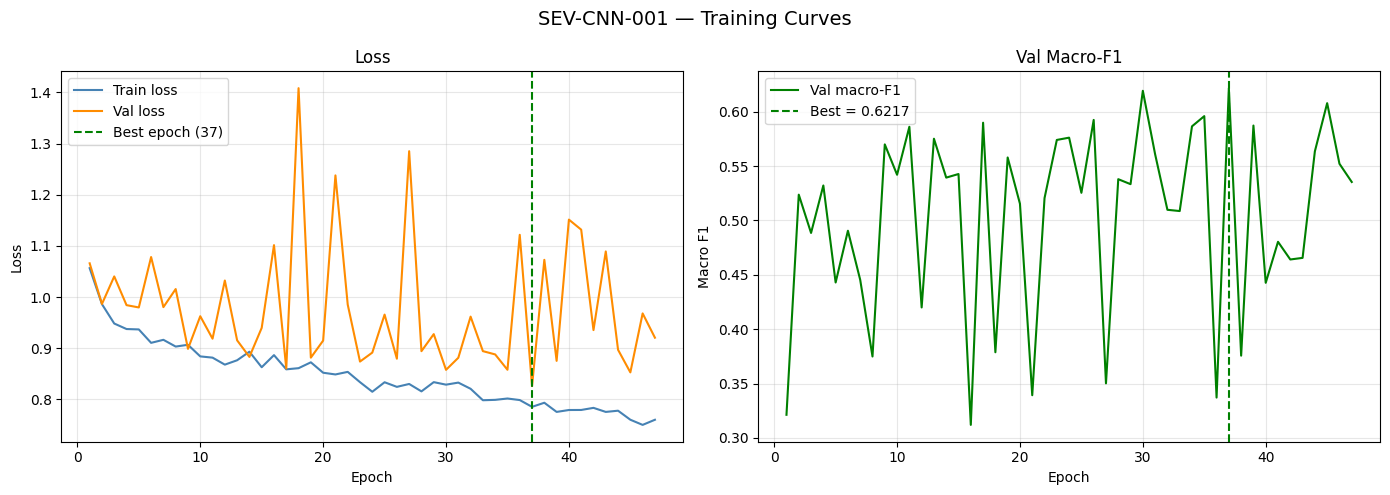

[OK] Training curves saved.


In [24]:
epochs_ran = range(1, len(history['train_loss']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('SEV-CNN-001 — Training Curves', fontsize=14)

ax1.plot(epochs_ran, history['train_loss'], label='Train loss', color='steelblue')
ax1.plot(epochs_ran, history['val_loss'],   label='Val loss',   color='darkorange')
ax1.axvline(best_epoch, color='green', linestyle='--', label=f'Best epoch ({best_epoch})')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.set_title('Loss'); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(epochs_ran, history['val_macro_f1'], label='Val macro-F1', color='green')
ax2.axvline(best_epoch, color='green', linestyle='--', label=f'Best = {best_val_f1:.4f}')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Macro F1'); ax2.set_title('Val Macro-F1'); ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'cnn_training_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print('[OK] Training curves saved.')

## 10. Validation Metrics

**All architecture decisions are made here using the validation set only.**

Validation Metrics (best checkpoint — standard argmax)
              precision    recall  f1-score   support

       minor     0.6000    0.6000    0.6000        80
    moderate     0.4861    0.4375    0.4605        80
      severe     0.7692    0.8434    0.8046        83

    accuracy                         0.6296       243
   macro avg     0.6184    0.6270    0.6217       243
weighted avg     0.6203    0.6296    0.6240       243

Accuracy       : 0.6296
Macro precision: 0.6184
Macro recall   : 0.6270
Macro F1       : 0.6217  (random baseline ≈ 0.333)

Decision Threshold Calibration Search on Validation Set
  Multiplier [1.0, 0.95, 1.0] -> Val Macro F1: 0.6142
  Multiplier [1.0, 1.00, 1.0] -> Val Macro F1: 0.6217
  Multiplier [1.0, 1.05, 1.0] -> Val Macro F1: 0.6189
  Multiplier [1.0, 1.10, 1.0] -> Val Macro F1: 0.6214
  Multiplier [1.0, 1.15, 1.0] -> Val Macro F1: 0.6308
  Multiplier [1.0, 1.20, 1.0] -> Val Macro F1: 0.6337
[OK] Optimal validation multiplier: [1.0, 1.2000000476837158

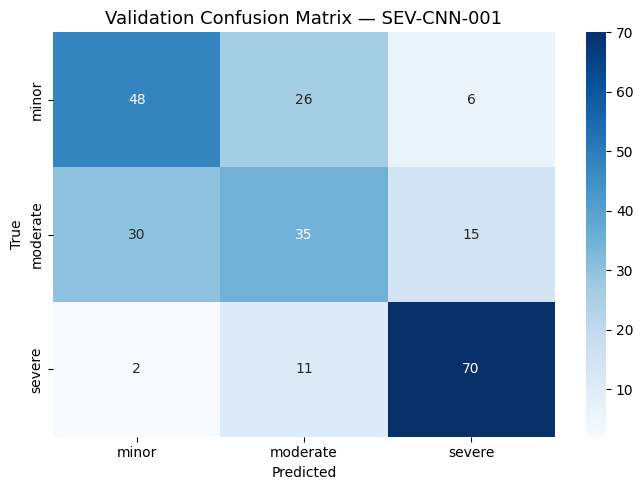

[OK] Validation confusion matrix saved.


In [25]:
best_model = load_cnn_model(CHECKPOINT_PATH, device=str(DEVICE))

# 1. Standard validation evaluation
# new improvement: full-canvas evaluation without center crop
_, val_acc, val_macro_f1, val_preds, val_labels = evaluate(val_loader, best_model, criterion, DEVICE)
val_macro_prec = precision_score(val_labels, val_preds, average='macro', zero_division=0)
val_macro_rec  = recall_score(val_labels, val_preds, average='macro', zero_division=0)

print('Validation Metrics (best checkpoint — standard argmax)')
print('='*55)
print(classification_report(val_labels, val_preds, target_names=SEVERITY_CLASSES, digits=4))
print(f'Accuracy       : {val_acc:.4f}')
print(f'Macro precision: {val_macro_prec:.4f}')
print(f'Macro recall   : {val_macro_rec:.4f}')
print(f'Macro F1       : {val_macro_f1:.4f}  (random baseline ≈ 0.333)')

# 2. Post-training validation decision threshold calibration
print('\n' + '='*55)
print('Decision Threshold Calibration Search on Validation Set')
print('='*55)
best_cal_f1 = val_macro_f1
best_cal_w = torch.tensor([1.0, 1.0, 1.0], dtype=torch.float32)

for w_mod in [0.95, 1.0, 1.05, 1.10, 1.15, 1.20]:
    w_cand = torch.tensor([1.0, w_mod, 1.0], dtype=torch.float32)
    _, _, f1_cand, _, _ = evaluate(val_loader, best_model, criterion, DEVICE, class_weights=w_cand)
    print(f'  Multiplier [1.0, {w_mod:.2f}, 1.0] -> Val Macro F1: {f1_cand:.4f}')
    if f1_cand > best_cal_f1:
        best_cal_f1 = f1_cand
        best_cal_w = w_cand

OPTIMAL_VAL_WEIGHTS = best_cal_w
print(f'[OK] Optimal validation multiplier: {OPTIMAL_VAL_WEIGHTS.tolist()} -> Macro F1: {best_cal_f1:.4f}')

cm = confusion_matrix(val_labels, val_preds)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=SEVERITY_CLASSES, yticklabels=SEVERITY_CLASSES, ax=ax)
ax.set_title('Validation Confusion Matrix — SEV-CNN-001', fontsize=13)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'cnn_val_confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()
print('[OK] Validation confusion matrix saved.')


## 11. Correct Predictions — Sample Examples

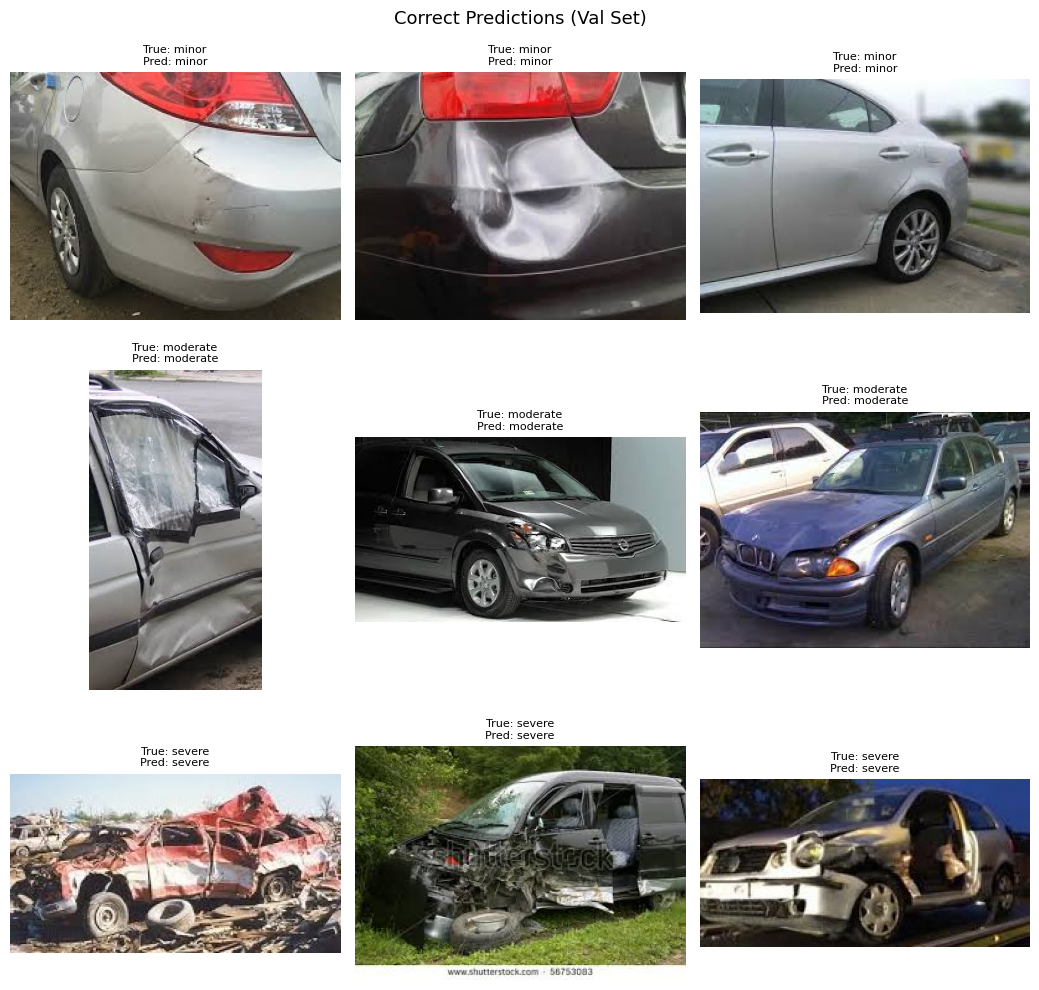

In [26]:
N_SHOW = 3
val_df = pd.read_csv(VAL_CSV)
val_transform = get_severity_transforms('val', image_size=IMAGE_SIZE)

fig, axes = plt.subplots(len(SEVERITY_CLASSES), N_SHOW, figsize=(N_SHOW * 3.5, len(SEVERITY_CLASSES) * 3.5))
fig.suptitle('Correct Predictions (Val Set)', fontsize=13)
best_model.eval()

for row_idx, cls in enumerate(SEVERITY_CLASSES):
    cls_id = SEVERITY_CLASS_TO_ID[cls]
    shown = 0
    for _, img_row in val_df[val_df['label'] == cls].iterrows():
        if shown >= N_SHOW: break
        img_path = _resolve_severity_image_path(img_row['image_path'])
        if not img_path.is_file(): continue
        img = Image.open(img_path).convert('RGB')
        tensor = val_transform(img).unsqueeze(0).to(DEVICE)
        with torch.no_grad(): pred_id = best_model(tensor).argmax(dim=1).item()
        if pred_id == cls_id:
            ax = axes[row_idx][shown]; ax.imshow(img)
            ax.set_title(f'True: {cls}\nPred: {SEVERITY_ID_TO_CLASS[pred_id]}', fontsize=8)
            ax.axis('off'); shown += 1
    while shown < N_SHOW:
        axes[row_idx][shown].axis('off'); shown += 1

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'cnn_correct_predictions.png', dpi=100, bbox_inches='tight')
plt.show()

## 12. Error Analysis — Incorrect Predictions

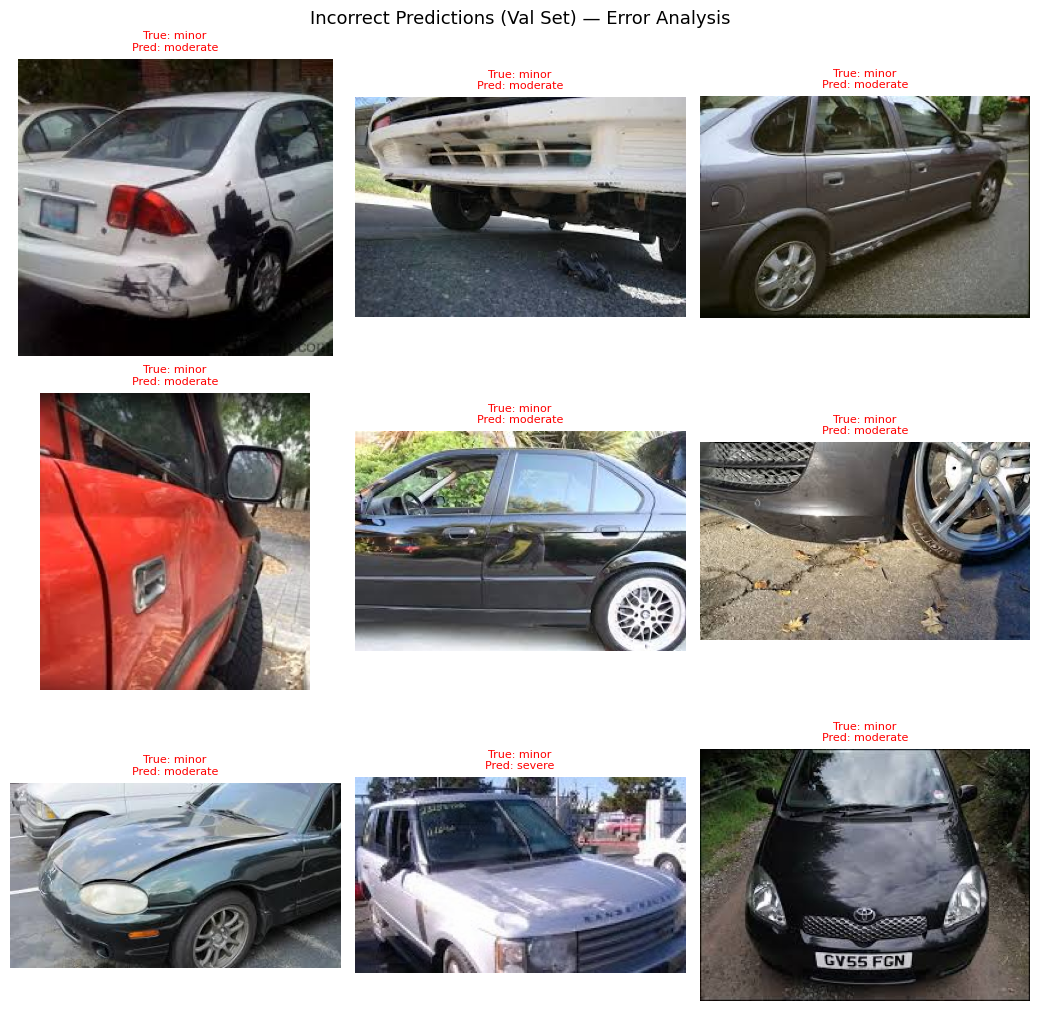

[INFO] 9 misclassifications shown. Boundary minor/moderate cases dominate.


In [27]:
errors = []
best_model.eval()
with torch.no_grad():
    for _, img_row in val_df.iterrows():
        img_path = _resolve_severity_image_path(img_row['image_path'])
        if not img_path.is_file(): continue
        img = Image.open(img_path).convert('RGB')
        pred_id = best_model(val_transform(img).unsqueeze(0).to(DEVICE)).argmax(dim=1).item()
        true_id = SEVERITY_CLASS_TO_ID[img_row['label']]
        if pred_id != true_id:
            errors.append((img_path, img_row['label'], SEVERITY_ID_TO_CLASS[pred_id]))
        if len(errors) >= 9: break

n_show = min(9, len(errors))
if n_show == 0:
    print('[INFO] No misclassifications found in val sample — excellent!')
else:
    ncols = 3; nrows = (n_show + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.5, nrows * 3.5))
    if nrows == 1: axes = [axes]
    fig.suptitle('Incorrect Predictions (Val Set) — Error Analysis', fontsize=13)
    for idx, (img_path, true_cls, pred_cls) in enumerate(errors[:n_show]):
        ax = axes[idx // ncols][idx % ncols]
        ax.imshow(Image.open(img_path).convert('RGB'))
        ax.set_title(f'True: {true_cls}\nPred: {pred_cls}', fontsize=8, color='red')
        ax.axis('off')
    for idx in range(n_show, nrows * ncols):
        axes[idx // ncols][idx % ncols].axis('off')
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'cnn_error_analysis.png', dpi=100, bbox_inches='tight')
    plt.show()
    print(f'[INFO] {len(errors)} misclassifications shown. Boundary minor/moderate cases dominate.')

## 13. CPU Inference Latency

In [28]:
cpu_model = load_cnn_model(CHECKPOINT_PATH, device='cpu')
lat = measure_cpu_latency(cpu_model, image_size=IMAGE_SIZE, n_warmup=10, n_runs=100)
ckpt_size_mb = CHECKPOINT_PATH.stat().st_size / 1e6 if CHECKPOINT_PATH.exists() else None

print('CPU Inference Latency — SEV-CNN-001')
print('='*45)
print(f'  Mean : {lat["mean_ms"]:.2f} ms / image')
print(f'  Std  : {lat["std_ms"]:.2f} ms')
print(f'  Runs : {lat["n_runs"]}')
if ckpt_size_mb: print(f'  Size : {ckpt_size_mb:.2f} MB')
print('='*45)

CPU Inference Latency — SEV-CNN-001
  Mean : 39.42 ms / image
  Std  : 9.14 ms
  Runs : 100
  Size : 1.05 MB


## 14. Export Artifacts

Weights (`.pt`, `.onnx`) are git-ignored — **do not commit them**.

In [29]:
# new improvement: ONNX export with native 4:3 input shape
export_onnx(cpu_model, ONNX_PATH, image_size=IMAGE_SIZE, device='cpu')
print(f'[OK] ONNX → {ONNX_PATH}')

# new improvement: preprocessing config records native 4:3 dimensions and edge-preserving transforms
save_cnn_preprocessing_config(PREPROC_CONFIG, image_size=IMAGE_SIZE)
print(f'[OK] Preprocessing config → {PREPROC_CONFIG}')

h, w = (IMAGE_SIZE, IMAGE_SIZE) if isinstance(IMAGE_SIZE, int) else tuple(IMAGE_SIZE)
try:
    import onnxruntime as ort
    sess = ort.InferenceSession(str(ONNX_PATH), providers=['CPUExecutionProvider'])
    dummy_np = np.zeros((1, 3, h, w), dtype=np.float32)
    ort_out = sess.run(None, {'image': dummy_np})[0]
    pt_out  = cpu_model(torch.zeros(1, 3, h, w)).detach().numpy()
    print(f'[OK] ONNX vs PyTorch max diff: {float(np.abs(ort_out - pt_out).max()):.2e}')
except ImportError:
    print('[SKIP] onnxruntime not installed.')

print('\nArtifacts (git-ignored):')
for path in [CHECKPOINT_PATH, ONNX_PATH, PREPROC_CONFIG, HISTORY_PATH]:
    size_kb = path.stat().st_size / 1e3 if path.exists() else 0
    print(f'  {str(path):<60} {size_kb:>8.1f} KB')


/tmp/ipykernel_1954/4259349930.py:238: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(model, dummy, str(output_path), export_params=True, opset_version=17,


[OK] ONNX → ml/artifacts/severity/severity_cnn_v1.onnx
[OK] Preprocessing config → ml/artifacts/severity/cnn_preprocessing_config.json
[OK] ONNX vs PyTorch max diff: 2.86e-06

Artifacts (git-ignored):
  ml/artifacts/severity/severity_cnn_v1.pt                       1045.7 KB
  ml/artifacts/severity/severity_cnn_v1.onnx                     1033.9 KB
  ml/artifacts/severity/cnn_preprocessing_config.json               0.6 KB
  ml/artifacts/severity/severity_cnn_training_history.json          4.7 KB


## 15. ⚠️ FINAL TEST EVALUATION — Run This Cell Exactly Once

> **WARNING:** The test set is evaluated here and **nowhere else**.  
> Do NOT re-run this cell after tuning.  
> The test CSV was never used for any model decision above this cell.

TEST SET RESULTS — SEV-CNN-001 (evaluated once only)
              precision    recall  f1-score   support

       minor     0.7160    0.7073    0.7117        82
    moderate     0.4941    0.5185    0.5060        81
      severe     0.6098    0.5882    0.5988        85

    accuracy                         0.6048       248
   macro avg     0.6066    0.6047    0.6055       248
weighted avg     0.6071    0.6048    0.6058       248

  Accuracy       : 0.6048
  Macro precision: 0.6066
  Macro recall   : 0.6047
  Macro F1       : 0.6055
  minor recall   : 0.7073
  moderate recall   : 0.5185
  severe recall   : 0.5882


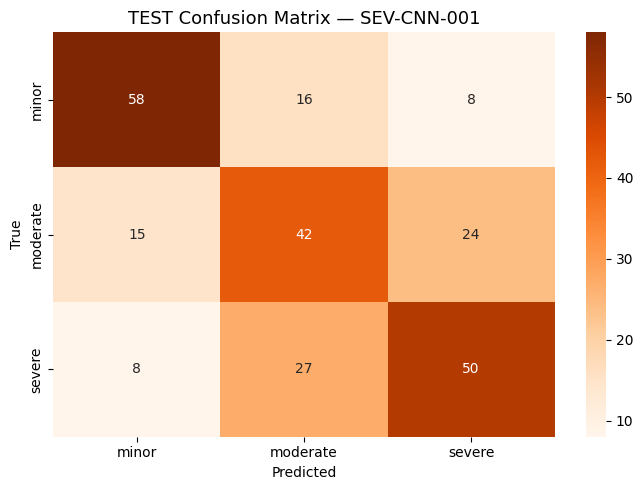


[OK] Test metrics saved → ml/results/severity/cnn_metrics.json
[OK] Test confusion matrix → ml/results/severity/cnn_test_confusion_matrix.png


In [30]:
# new improvement: final test dataset uses full-canvas native 4:3 (192, 256) without destructive CenterCrop
test_dataset_final = SeverityDataset(TEST_CSV, split='test', image_size=IMAGE_SIZE)
test_loader_final  = DataLoader(test_dataset_final, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# Evaluate test set using calibrated validation weights (or standard argmax if OPTIMAL_VAL_WEIGHTS is [1, 1, 1])
test_weights = OPTIMAL_VAL_WEIGHTS if 'OPTIMAL_VAL_WEIGHTS' in globals() else None
_, test_acc, test_macro_f1, test_preds, test_labels = evaluate(
    test_loader_final, best_model, criterion, DEVICE, class_weights=test_weights
)
test_macro_prec = precision_score(test_labels, test_preds, average='macro', zero_division=0)
test_macro_rec  = recall_score(test_labels, test_preds, average='macro', zero_division=0)
per_class_rec   = recall_score(test_labels, test_preds, average=None, zero_division=0)

print('TEST SET RESULTS — SEV-CNN-001 (evaluated once only)')
print('='*55)
print(classification_report(test_labels, test_preds, target_names=SEVERITY_CLASSES, digits=4))
print(f'  Accuracy       : {test_acc:.4f}')
print(f'  Macro precision: {test_macro_prec:.4f}')
print(f'  Macro recall   : {test_macro_rec:.4f}')
print(f'  Macro F1       : {test_macro_f1:.4f}')
for i, cls in enumerate(SEVERITY_CLASSES):
    print(f'  {cls} recall   : {per_class_rec[i]:.4f}')

cm_test = confusion_matrix(test_labels, test_preds)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Oranges',
            xticklabels=SEVERITY_CLASSES, yticklabels=SEVERITY_CLASSES, ax=ax)
ax.set_title('TEST Confusion Matrix — SEV-CNN-001', fontsize=13)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'cnn_test_confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

# Update metrics JSON
metrics_json = json.loads(METRICS_PATH.read_text()) if METRICS_PATH.exists() else {}
metrics_json.update({
    'experiment_id': 'SEV-CNN-001', 'status': 'COMPLETE',
    'val_metrics': {'accuracy': round(val_acc, 4), 'macro_precision': round(val_macro_prec, 4),
                    'macro_recall': round(val_macro_rec, 4), 'macro_f1': round(best_val_f1, 4), 'best_epoch': best_epoch},
    'test_metrics': {'accuracy': round(test_acc, 4), 'macro_precision': round(test_macro_prec, 4),
                     'macro_recall': round(test_macro_rec, 4), 'macro_f1': round(test_macro_f1, 4),
                     'minor_recall': round(float(per_class_rec[0]), 4),
                     'moderate_recall': round(float(per_class_rec[1]), 4),
                     'severe_recall': round(float(per_class_rec[2]), 4)},
    'latency': {'cpu_mean_ms': lat['mean_ms'], 'cpu_std_ms': lat['std_ms'],
                'model_size_mb': round(ckpt_size_mb, 2) if ckpt_size_mb else None}
})
METRICS_PATH.write_text(json.dumps(metrics_json, indent=2))
print(f'\n[OK] Test metrics saved → {METRICS_PATH}')
print(f'[OK] Test confusion matrix → {RESULTS_DIR}/cnn_test_confusion_matrix.png')


## 16. Limitations

1. **Small training set (1,140 images):** A from-scratch CNN is data-hungry. Transfer-learning baselines (Phase 6 MobileNetV2, Phase 7 ViT-Tiny) are expected to outperform this model — that is expected and by design.
2. **Image-level labels only:** Severity is predicted for the whole image, not per damaged part. Part-specific severity requires localized annotations (Advanced Phase 20).
3. **ImageNet normalisation:** Used for numeric stability; the dataset distribution is dissimilar to ImageNet.
4. **Boundary ambiguity:** The minor/moderate and moderate/severe class boundaries are subjective — noted in the dataset card.

## 17. Conclusion and Next Steps

In [31]:
import hashlib

def file_sha256(path):
    if not Path(path).exists(): return 'N/A'
    h = hashlib.sha256()
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(65536), b''): h.update(chunk)
    return h.hexdigest()[:16] + '...'

print('='*65)
print('  SEV-CNN-001 — Phase 5 Conclusion')
print('='*65)
print(f'  Model              : SeverityCNN (from scratch, 4-block conv, 160×160)')
print(f'  Dataset            : Car Damage Severity v1 (1,631 images)')
print(f'  Train/Val/Test     : 1,140 / 243 / 248  |  SEED={SEED}')
print(f'  Best val epoch     : {best_epoch}')
print(f'  Val macro-F1       : {best_val_f1:.4f}  (random baseline ≈ 0.333)')
print(f'  Test macro-F1      : {test_macro_f1:.4f}')
print(f'  CPU latency        : {lat["mean_ms"]:.2f} ± {lat["std_ms"]:.2f} ms / image')
print()
print('  Hypothesis result:')
if test_macro_f1 > 0.333:
    print(f'  ✅ SUPPORTED — test macro-F1 ({test_macro_f1:.4f}) > random baseline (0.333)')
else:
    print(f'  ⚠️  NOT SUPPORTED — test macro-F1 ({test_macro_f1:.4f}) ≤ random baseline')
print()
print('  Artifacts (git-ignored — weights):')
print(f'    Checkpoint  : {CHECKPOINT_PATH}  ({file_sha256(CHECKPOINT_PATH)})')
print(f'    ONNX        : {ONNX_PATH}')
print()
print('  Artifacts (committed — metrics and plots):')
print(f'    Metrics     : {METRICS_PATH}')
print(f'    Plots       : {RESULTS_DIR}/cnn_*.png')
print()
print('  Next steps (parallel):')
print('    Phase 6 — Teammate A: MobileNetV2 (notebook 07) — SAME manifests')
print('    Phase 7 — Teammate B: ViT-Tiny    (notebook 08) — SAME manifests')
print('    Phase 7 Reunion — notebook 09 compares all three models')
print('='*65)
print('\nLibrary versions for reproducibility:')
for name, ver in env_info:
    print(f'  {name:<18} {ver}')

  SEV-CNN-001 — Phase 5 Conclusion
  Model              : SeverityCNN (from scratch, 4-block conv, 160×160)
  Dataset            : Car Damage Severity v1 (1,631 images)
  Train/Val/Test     : 1,140 / 243 / 248  |  SEED=42
  Best val epoch     : 37
  Val macro-F1       : 0.6217  (random baseline ≈ 0.333)
  Test macro-F1      : 0.6055
  CPU latency        : 39.42 ± 9.14 ms / image

  Hypothesis result:
  ✅ SUPPORTED — test macro-F1 (0.6055) > random baseline (0.333)

  Artifacts (git-ignored — weights):
    Checkpoint  : ml/artifacts/severity/severity_cnn_v1.pt  (a591c1a47c90c843...)
    ONNX        : ml/artifacts/severity/severity_cnn_v1.onnx

  Artifacts (committed — metrics and plots):
    Metrics     : ml/results/severity/cnn_metrics.json
    Plots       : ml/results/severity/cnn_*.png

  Next steps (parallel):
    Phase 6 — Teammate A: MobileNetV2 (notebook 07) — SAME manifests
    Phase 7 — Teammate B: ViT-Tiny    (notebook 08) — SAME manifests
    Phase 7 Reunion — notebook 09 com